## `sim_class.py`에 대한 검증 및 시각화 자료

#### by 김재헌

### 모듈 및 클래스 load

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sim_class import PhotonicGlassMCSimulator

sim = PhotonicGlassMCSimulator(
    film_thickness = 77.0, #um
    phi = 0.56, 
    fine_roughness=0.5,
    coarse_roughness=0.9,
    r_i=0.138, 
    n_m=1.0, 
    k_p=2e-5, 
    pdi=0.03, 
    detect_angle=90
    )


In [5]:
from sim_class_SL_v01 import PhotonicGlassMCSimulator2

sim2 = PhotonicGlassMCSimulator2(
        film_thickness = 77.0, #um
        phi = 0.56, 
        fine_roughness=0.5,
        coarse_roughness=0.9,
        r_i=0.138, 
        n_m=1.0, 
        k_p=2e-5, 
        pdi=0.03, 
        detect_angle=90
    )

In [7]:
wvl = 0.55 # um
wvl_array = np.linspace(0.400, 0.800, 1000)
theta_array = np.linspace(1e-4, np.pi, 1000)    # radians
theta_deg = np.degrees(theta_array)             # degrees  

### Step 1. effective index, absorption coefficient 확인

In [33]:
n_p = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
n_eff = sim._get_n_eff_ps_matrix(wvl)
mu_a = sim._get_mu_a(wvl, n_eff)

print("n_p                      =", n_p)
print("n_eff                    =", n_eff)
print("mu_a [1/um]              =", mu_a)
print("absorption length [um]   =", np.inf if mu_a == 0 else 1 / mu_a)

n_p                      = (1.5958939298996344+2e-05j)
n_eff                    = (1.3238414651006658+1.0657361486477478e-05j)
mu_a [1/um]              = 0.00024349882583686138
absorption length [um]   = 4106.795983771918


/home/shinbo/miniconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/shinbo/miniconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


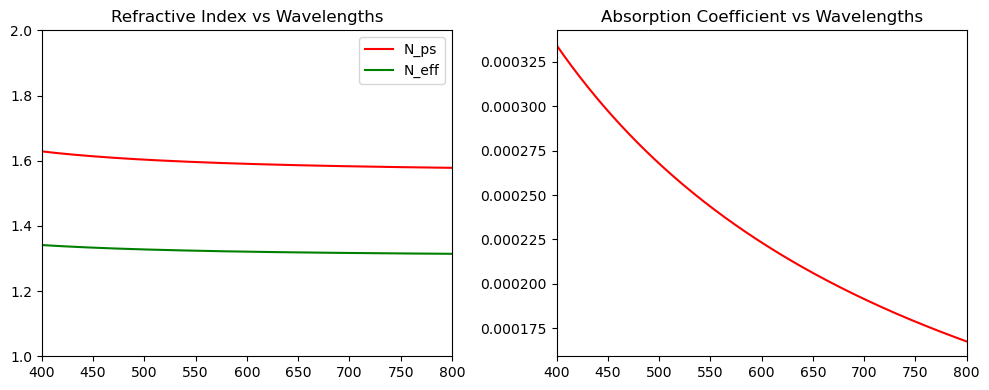

In [34]:
n_p_array = sim.get_n_p_real_sellmeier(wvl_array) + 1j * sim.k_p
n_eff_array = [sim._get_n_eff_ps_matrix(wvl) for wvl in wvl_array]
mu_a_array = [sim._get_mu_a(wvl, sim._get_n_eff_ps_matrix(wvl)) for wvl in wvl_array] 
x = wvl_array * 1000


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, n_p_array, color='red', label='N_ps')
ax1.plot(x, np.real(n_eff_array), color='green', label='N_eff')
ax1.set_title("Refractive Index vs Wavelengths")
ax1.legend()
ax1.set_ylim(1, 2)
ax1.set_xlim(400, 800)

ax2.plot(x, mu_a_array, color='red', label='mu_a')
ax2.set_title("Absorption Coefficient vs Wavelengths")
ax2.set_xlim(400, 800)

plt.tight_layout()
plt.show()

### Step 2. Schulz distribution 확인

SI에서는 실험에서 존재하는 입자 크기의 polydispersity를 반영하기 위해 Schulz dirtribution을 이용한다고 말한다.
polydipersity 옵션을 작동시킬 때, 입자의 크기가 올바르게 분포하는지 확인한다.

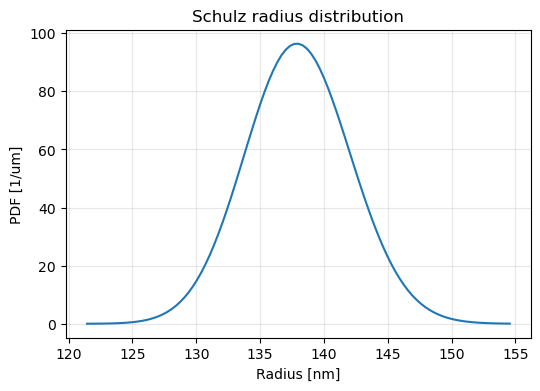

mean radius [um] ≈ 0.13799927363919218
normalization = 1.0


In [6]:
radius_samples, size_pdf = sim._get_schulz_distribution(
    n_points=101,
    n_std=4.0,
)

plt.figure(figsize=(6, 4))
plt.plot(radius_samples * 1000, size_pdf)
plt.xlabel("Radius [nm]")
plt.ylabel("PDF [1/um]")
plt.title("Schulz radius distribution")
plt.grid(True, alpha=0.3)
plt.show()

print("mean radius [um] ≈", np.trapezoid(radius_samples * size_pdf, radius_samples))
print("normalization =", np.trapezoid(size_pdf, radius_samples))

### Step 3. structure factor 확인

wavelength가 550nm일 때의 scattering wavevector의 크기(q)와, Structure Factor를 확인했다. 

논문에서는 structure factor 계산에 있어 Percus-Yevick approximation을 이용한다.

In [37]:
def check_x_range(sim, wavelengths, theta_array):
    rows = []

    d = 2.0 * sim.r_i

    for wavelength in wavelengths:
        n_eff = np.real(sim._get_n_eff_ps_matrix(wavelength))
        q = sim.get_q(n_eff, theta_array, wavelength)
        x = q * d
        S = sim._get_structure_factor_ginoza(q)

        imax = np.argmax(S)

        rows.append({
            "wavelength_nm": wavelength * 1000,
            "x_min": np.min(x),
            "x_max": np.max(x),
            "x_at_Smax": x[imax],
            "theta_at_Smax_deg": np.degrees(theta_array[imax]),
            "Smax": np.max(S),
            "S_at_back": S[-1],
        })

    return pd.DataFrame(rows)

df_x = check_x_range(
    sim,
    wavelengths=np.linspace(0.4, 0.8, 9),
    theta_array=theta_array
)

display(df_x)
df_x.to_csv("Sq_validation.csv", index=False)

,wavelength_nm,x_min,x_max,x_at_Smax,theta_at_Smax_deg,Smax,S_at_back
0,400.0,0.000581,11.629676,7.249201,77.120392,4.552343,0.875372
1,450.0,0.000514,10.275889,7.249176,89.732603,4.552348,0.474781
2,500.0,0.000461,9.210293,7.247218,103.786210,4.552622,0.714647
3,550.0,0.000417,8.348188,7.242903,120.362259,4.552423,0.906152
4,600.0,0.000382,7.635592,7.246164,143.244413,4.552676,2.498554
5,650.0,0.000352,7.036292,7.036292,180.000000,3.466252,3.466252
6,700.0,0.000326,6.525013,6.525013,180.000000,0.828955,0.828955
7,750.0,0.000304,6.083539,6.083539,180.000000,0.315569,0.315569
8,800.0,0.000285,5.698393,0.000285,0.005730,0.193028,0.166105


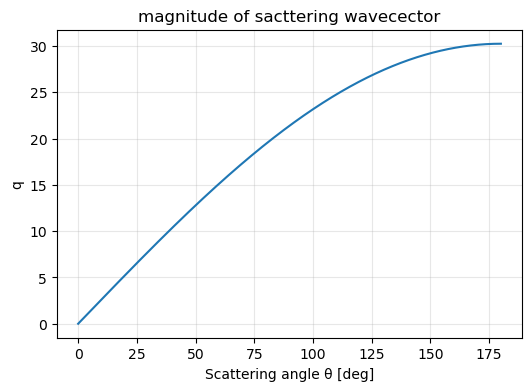

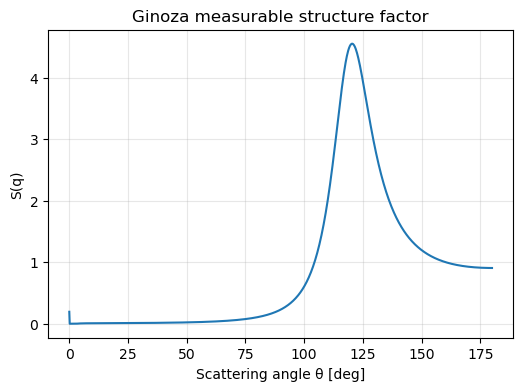

In [7]:
q = sim.get_q(np.real(n_eff), theta_array, wvl)
S_q = sim._get_structure_factor_ginoza(q)

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, q)
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("q")
plt.title("magnitude of sacttering wavecector")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_q)
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Ginoza measurable structure factor")
plt.grid(True, alpha=0.3)
plt.show()

Structure Factor의 Variable : 
- 정해진 volume fraction($\phi$)에 대해서 $qd$에 dependant하며, 이때 $d$는 입자의 지름(278nm, 상수)이다.
- 따라서 Structure Factor는 $\theta$(scattering angle)과 wavelength 모두에 depedant하기에 두 변수에 따른 heatmap을 그린다.

그림에서 structure factor의 피크가 보이는 부분을 흰색 점선으로 표시했다. 흰색 점에서의 wavelength와 $\theta$를 이용해 $q$를 계산하면, 모두 동일한 $q$ 값을 지칭함을 알 수 있다.

q_peak [1/um] = 26.242400640325066
theta_peak at 550 nm [deg] = 120.36225874905095


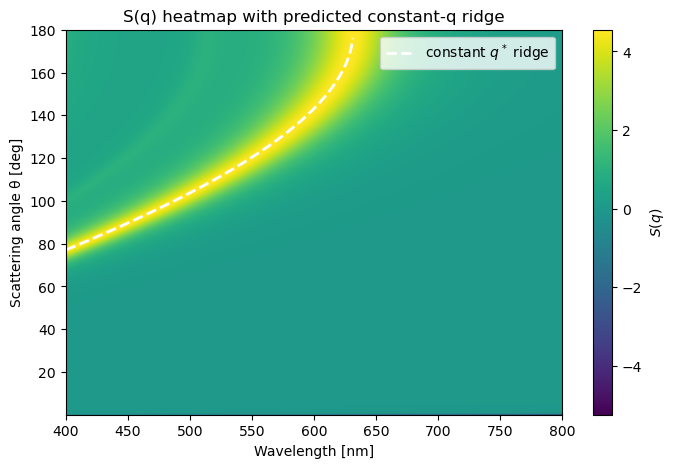

In [35]:
S_map = np.zeros((len(theta_array), len(wvl_array)))
S_max = np.zeros(len(theta_array))
S_min = np.zeros(len(theta_array))

for j, wvl in enumerate(wvl_array):
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    q = sim.get_q(np.real(n_eff), theta_array, wvl)
    S_q = sim._get_structure_factor_ginoza(q)
    S_map[:, j] = S_q
    
    S_max[j] = np.max(S_q)
    S_min[j] = np.min(S_q)

# 1) 기준 파장에서 S(q)의 peak q* 찾기
wvl0 = 0.55  # um
n_eff0 = sim._get_n_eff_ps_matrix(wvl0)
q0 = sim.get_q(np.real(n_eff0), theta_array, wvl0)
S0 = sim._get_structure_factor_ginoza(q0)

idx_peak = np.argmax(S0)
q_peak = q0[idx_peak]
theta_peak_deg = np.degrees(theta_array[idx_peak])

print("q_peak [1/um] =", q_peak)
print("theta_peak at 550 nm [deg] =", theta_peak_deg)

# 2) 각 wavelength에서 q_peak에 해당하는 theta 예측
wvls = np.linspace(0.400, 0.800, 300)
theta_ridge = []

for wvl in wvls:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    arg = q_peak * wvl / (4.0 * np.pi * np.real(n_eff))
    
    if arg <= 1.0:
        theta_ridge.append(2.0 * np.arcsin(arg))
    else:
        theta_ridge.append(np.nan)

theta_ridge = np.array(theta_ridge)

# 3) heatmap 위에 overlay
plt.figure(figsize=(8, 5))
plt.imshow(
    S_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$S(q)$")
plt.plot(wvls * 1000, np.degrees(theta_ridge), "w--", linewidth=2, label=r"constant $q^*$ ridge")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("S(q) heatmap with predicted constant-q ridge")
plt.legend()
plt.show()

각 파장에서 생성되는 Structure의 최댓값과 최솟값

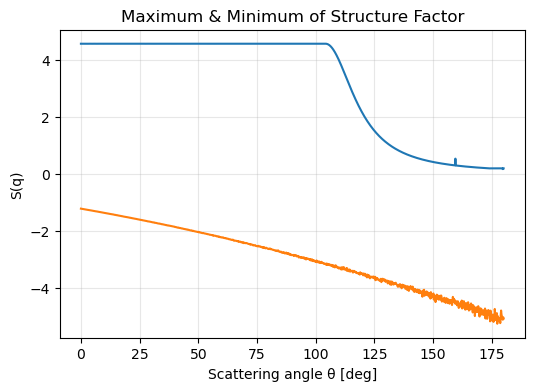

In [36]:
plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_max, label="S(q) max")
plt.plot(theta_deg, S_min, label="S(q) min")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Maximum & Minimum of Structure Factor")
plt.grid(True, alpha=0.3)
plt.show()

### Step 4. Mie differential cross section 확인

`csca_mie`는 구조 인자를 곱하지 않은 단일입자 산란 단면적:
$C_{sca}^{Mie} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}sinθdθ$

csca_sample은 구조 인자까지 포함한 sample effective scattering cross section:
$C_{sca}^{sample} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}S(q)sinθdθ$

Monte Carlo의 bulk step size에는 csca_sample이 들어가야 해. SI에서 scattering length를
$l_{sca}= \frac{1}{ρC_{sca}^{sample}}$



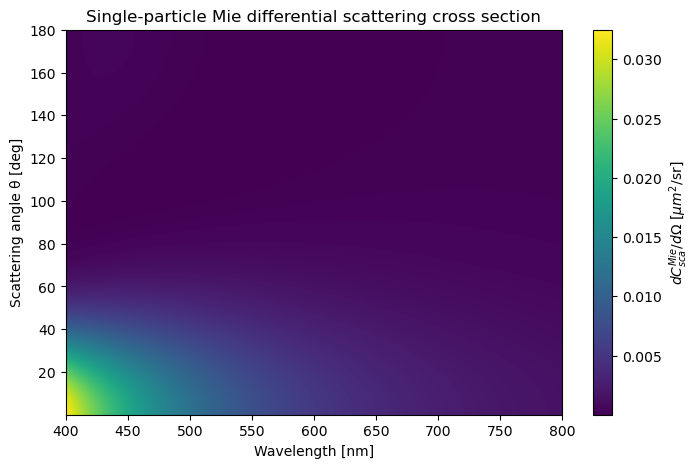

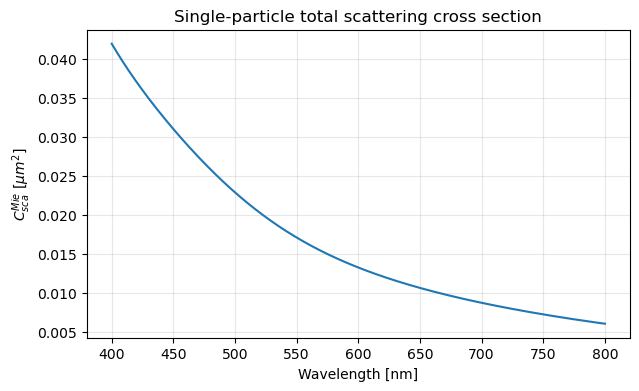

In [10]:
mie_map = np.zeros((len(theta_array), len(wvl_array)))
csca_mie_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p_complex,
        n_eff_complex=n_eff_complex,
        theta_array=theta_array,
        backend="internal",
    )
    
    mie_map[:, j] = diff_mie
    csca_mie_list.append(csca_mie)

csca_mie_list = np.asarray(csca_mie_list)

plt.figure(figsize=(8, 5))
plt.imshow(
    mie_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$dC_{sca}^{Mie}/d\Omega$ [$\mu m^2$/sr]")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Single-particle Mie differential scattering cross section")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_mie_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Mie}$ [$\mu m^2$]")
plt.title("Single-particle total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
rho = 3 * sim.phi / (4*np.pi*sim.r_i**3)
geom = np.pi * sim.r_i**2

for wvl in [0.4, 0.5, 0.8]:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    n_p = sim.get_n_p_real_sellmeier(wvl) + 1j*sim.k_p

    phase, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )

    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p,
        n_eff_complex=n_eff,
        theta_array=theta_array,
        backend="internal",
    )

    print(f"\nλ={wvl*1000:.0f} nm")
    print("csca_mie     =", csca_mie, "Q_mie =", csca_mie/geom)
    print("csca_sample  =", csca_sample, "Q_sample =", csca_sample/geom)
    print("Weigthed S(q)=", csca_sample / csca_mie)
    print("l_scat_mie   =", 1/(rho*csca_mie))
    print("l_scat_sample=", 1/(rho*csca_sample))
    print("rho          =", rho)


λ=400 nm
csca_mie     = 0.04191323182631486 Q_mie = 0.7005563984577355
csca_sample  = 0.0043496496863758335 Q_sample = 0.07270197944810189
Weigthed S(q)= 0.10377748259548297
l_scat_mie   = 0.469014956247311
l_scat_sample= 4.519428921546468
rho          = 50.870049297428714

λ=500 nm
csca_mie     = 0.02289894204719225 Q_mie = 0.3827431021198794
csca_sample  = 0.001714742781169282 Q_sample = 0.02866097350916146
Weigthed S(q)= 0.07488305693928489
l_scat_mie   = 0.8584646640307481
l_scat_sample= 11.46407076739389
rho          = 50.870049297428714

λ=800 nm
csca_mie     = 0.006105823220698712 Q_mie = 0.10205544499259363
csca_sample  = 0.00016779924243826095 Q_sample = 0.0028046711700403875
Weigthed S(q)= 0.027481837644663918
l_scat_mie   = 3.219538443982814
l_scat_sample= 117.15149785873014
rho          = 50.870049297428714


### Step 4. phase function / sample cross section 확인 & Step 5. CDF 확인

In [12]:
phase_map = np.zeros((len(theta_array), len(wvl_array)))
pdf_map = np.zeros((len(theta_array), len(wvl_array)))
cdf_map = np.zeros((len(theta_array), len(wvl_array)))
csca_sample_list = []
l_scat_list = []
l_star_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    phase_func, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )
    cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)
    l_scat = sim._get_l_scat(csca_sample)
    l_star = sim._get_l_star(l_scat, theta_pdf, theta_array)
    
    cdf_map[:, j] = cdf
    pdf_map[:, j] = theta_pdf
    phase_map[:, j] = phase_func
    csca_sample_list.append(csca_sample)
    l_scat_list.append(l_scat)
    l_star_list.append(l_star)

csca_sample_list = np.asarray(csca_sample_list)
l_scat_list = np.asarray(l_scat_list)

#### Phase Function Heat Map

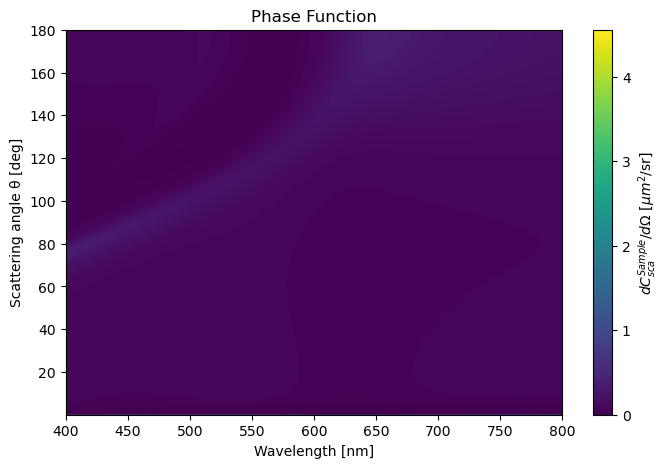

In [14]:
plt.figure(figsize=(8, 5))
plt.imshow(
    phase_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$dC_{sca}^{Sample}/d\Omega$ [$\mu m^2$/sr]")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Phase Function")
plt.show()

#### Single-particle total scattering cross section

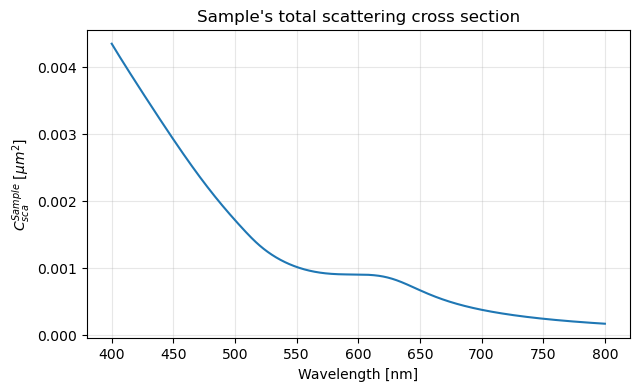

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_sample_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Sample}$ [$\mu m^2$]")
plt.title("Sample's total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

#### $l_{scat}$ & $l_{trans}$ by wavelength

논문에서는 transport length가 8 - 47um 범위에 존재한다고 말함

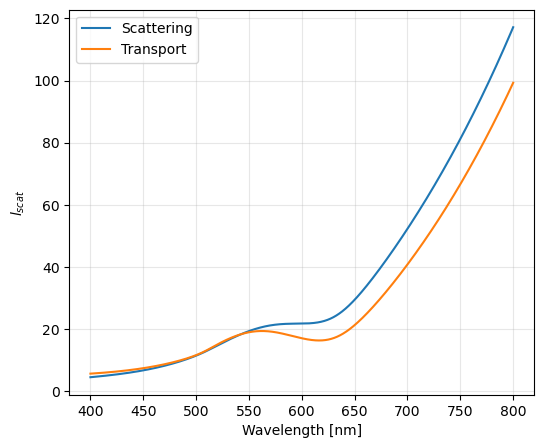

5.669884639797443 99.26680231680973


In [19]:
plt.figure(figsize=(6, 5))
plt.plot(wvl_array * 1000, l_scat_list, label="Scattering")
plt.plot(wvl_array * 1000, l_star_list, label="Transport")
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$l_{scat}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(l_star_list[0], l_star_list[-1])

$l_{trans} = \frac{l_{sca}}{1-<\cos >}$ 인데, $l_{trans}$이 너무 작기에, $l_{sca}$을 만드는 $C_{sca}^{sample}$을 조사한다

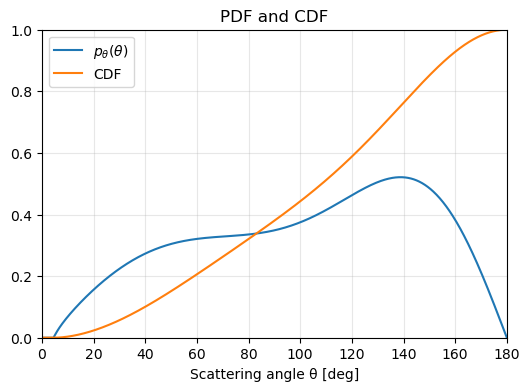

In [ ]:
cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, theta_pdf, label=r"$p_\theta(\theta)$")
plt.plot(theta_deg, cdf, label="CDF")
plt.xlabel("Scattering angle θ [deg]")
plt.title("PDF and CDF")
plt.legend()
plt.ylim(0, 1.0)
plt.xlim(0, 180)
plt.grid(True, alpha=0.3)
plt.show()

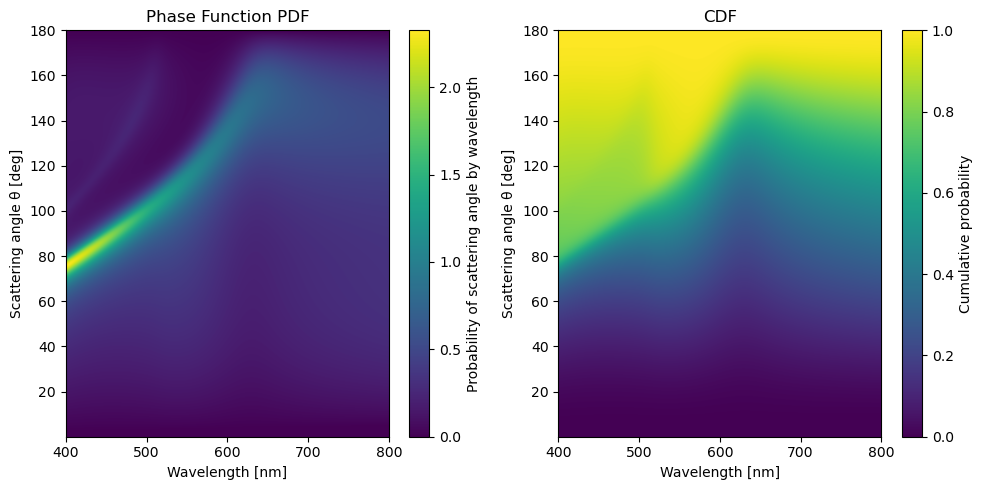

'\nplt.figure(figsize=(4, 5))\nplt.imshow(\n    pdf_map,\n    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],\n    aspect="auto",\n    origin="lower"\n)\nplt.colorbar(label=r"Proability of scattering angle by the wavelength")\nplt.xlabel("Wavelength [nm]")\nplt.ylabel("Scattering angle θ [deg]")\nplt.title("Phase Function PDF")\nplt.show()\n\nplt.figure(figsize=(4, 5))\nplt.imshow(\n    cdf_map,\n    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],\n    aspect="auto",\n    origin="lower"\n)\nplt.colorbar(label=r"Proability of scattering angle by the wavelength")\nplt.xlabel("Wavelength [nm]")\nplt.ylabel("Scattering angle θ [deg]")\nplt.title("CDF")\nplt.show()\n'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------------- PDF ----------------
im1 = axes[0].imshow(pdf_map, extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower")

axes[0].set_xlabel("Wavelength [nm]")
axes[0].set_ylabel("Scattering angle θ [deg]")
axes[0].set_title("Phase Function PDF")

fig.colorbar(im1, ax=axes[0], label="Probability of scattering angle by wavelength")

# ---------------- CDF ----------------
im2 = axes[1].imshow(cdf_map, extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower")

axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Scattering angle θ [deg]")
axes[1].set_title("CDF")

fig.colorbar(im2, ax=axes[1], label="Cumulative probability")

plt.tight_layout()
plt.show()

In [16]:
for wavelength in [0.4, 0.5, 0.6, 0.7, 0.8]:
    n_eff_complex = sim._get_n_eff_ps_matrix(wavelength)
    n_p_complex = sim.get_n_p_real_sellmeier(wavelength) + 1j * sim.k_p

    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wavelength,
        n_p_complex=n_p_complex,
        n_eff_complex=n_eff_complex,
        theta_array=theta_array,
        backend="internal"
    )

    q = sim.get_q(np.real(n_eff_complex), theta_array, wavelength)
    S_q = sim._get_structure_factor_ginoza(q)
    diff_sample = diff_mie * S_q

    # backward hemisphere contribution: theta > 90 deg
    mask_back = theta_array > np.pi / 2

    c_back = 2*np.pi*np.trapezoid(
        diff_sample[mask_back] * np.sin(theta_array[mask_back]),
        theta_array[mask_back]
    )

    c_total = 2*np.pi*np.trapezoid(
        diff_sample * np.sin(theta_array),
        theta_array
    )

    print(
        wavelength,
        "C_total =", c_total,
        "C_back =", c_back,
        "back fraction =", c_back / c_total
    )

0.4 C_total = 0.0043496496863758335 C_back = 0.0009364480125445157 back fraction = 0.21529274310933588
0.5 C_total = 0.001714742781169282 C_back = 0.0009267738976959844 back fraction = 0.5404740045407964
0.6 C_total = 0.0009025737263143906 C_back = 0.000642783814584941 back fraction = 0.7121676554996929
0.7 C_total = 0.000375935926147447 C_back = 0.0002563996160107505 back fraction = 0.6820300965600908
0.8 C_total = 0.00016779924243826095 C_back = 0.00010395602283130894 back fraction = 0.6195261749739895


파장별 인자 분석

In [25]:
def diagnostic_one_wavelength(
    sim,
    wavelength,
    theta_array,
    backend="internal",
    use_polydispersity=False,
    radius_samples=None,
    size_pdf=None,
    run_mc=False,
    N_photons=2000,
):
    """
    wavelength 단위: μm
    theta_array 단위: rad

    출력:
    csca_mie, csca_sample, weighted_S, l_scat, g, l_transport,
    backward cross-section fraction, optional R/T/A.
    """

    theta_array = np.asarray(theta_array, dtype=float)

    # 1. Optical constants
    n_eff_complex = sim._get_n_eff_ps_matrix(wavelength)
    n_eff_real = float(np.real(n_eff_complex))
    n_p_complex = sim.get_n_p_real_sellmeier(wavelength) + 1j * sim.k_p
    mu_a = sim._get_mu_a(wavelength, n_eff_complex)

    # 2. Mie-only cross section
    if use_polydispersity:
        if radius_samples is None or size_pdf is None:
            radius_samples, size_pdf = sim._get_schulz_distribution()

        diff_mie, csca_mie = sim._get_polydisperse_form_factor_absorbing(
            wavelength=wavelength,
            n_p_complex=n_p_complex,
            n_eff_complex=n_eff_complex,
            theta_array=theta_array,
            radius_samples=radius_samples,
            size_pdf=size_pdf,
            backend=backend,
        )
    else:
        diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
            wavelength=wavelength,
            n_p_complex=n_p_complex,
            n_eff_complex=n_eff_complex,
            theta_array=theta_array,
            backend=backend,
        )

    # 3. Structure factor
    q = sim.get_q(np.real(n_eff_complex), theta_array, wavelength)
    S_q = sim._get_structure_factor_ginoza(q)
    S_q = np.asarray(np.real_if_close(S_q), dtype=float)
    S_q = np.clip(S_q, 0.0, None)

    # 4. Sample differential cross-section
    diff_sample = diff_mie * S_q

    csca_sample = 2.0 * np.pi * np.trapezoid(
        diff_sample * np.sin(theta_array),
        theta_array
    )

    weighted_S = csca_sample / csca_mie

    # 5. Scattering length
    rho = (sim.phi * 3.0) / (4.0 * np.pi * sim.r_i**3)
    l_scat = sim._get_l_scat(csca_sample)
    l_scat_mie = sim._get_l_scat(csca_mie)

    # 6. Phase function and theta PDF
    phase = diff_sample / csca_sample
    phase_norm = 2.0 * np.pi * np.trapezoid(
        phase * np.sin(theta_array),
        theta_array
    )
    phase = phase / phase_norm

    cdf_norm, theta_pdf = sim._cdf_phase(phase, theta_array)

    # 7. Anisotropy factor and transport length
    g = np.trapezoid(
        np.cos(theta_array) * theta_pdf,
        theta_array
    )

    l_transport = l_scat / (1.0 - g)

    # 8. Backward hemisphere contribution
    mask_back = theta_array > (np.pi / 2.0)

    C_back = 2.0 * np.pi * np.trapezoid(
        diff_sample[mask_back] * np.sin(theta_array[mask_back]),
        theta_array[mask_back]
    )

    back_fraction = C_back / csca_sample

    # 9. Surface phase and CDF for optional MC
    phase_surf = diff_mie / csca_mie
    phase_surf_norm = 2.0 * np.pi * np.trapezoid(
        phase_surf * np.sin(theta_array),
        theta_array
    )
    phase_surf = phase_surf / phase_surf_norm
    cdf_surf, theta_pdf_surf = sim._cdf_phase(phase_surf, theta_array)

    result = {
        "wavelength_um": wavelength,
        "wavelength_nm": wavelength * 1000.0,
        "n_eff_real": n_eff_real,
        "n_eff_imag": float(np.imag(n_eff_complex)),
        "mu_a": mu_a,
        "rho": rho,
        "csca_mie": csca_mie,
        "csca_sample": csca_sample,
        "Q_mie": csca_mie / (np.pi * sim.r_i**2),
        "Q_sample": csca_sample / (np.pi * sim.r_i**2),
        "weighted_S": weighted_S,
        "S_min": float(np.min(S_q)),
        "S_max": float(np.max(S_q)),
        "C_back": C_back,
        "back_fraction": back_fraction,
        "g": g,
        "l_scat_mie_um": l_scat_mie,
        "l_scat_sample_um": l_scat,
        "l_transport_um": l_transport,
        "lambda_over_l_transport": wavelength / l_transport,
    }

    # 10. Optional Monte Carlo R/T/A
    if run_mc:
        R, T, A, diag = sim._run_single_wavelength(
            N_photons=N_photons,
            theta_array=theta_array,
            mu_a=mu_a,
            l_scat_norm=l_scat,
            cdf_norm=cdf_norm,
            l_scat_surf=l_scat_mie,
            cdf_surf=cdf_surf,
            n_eff_real=n_eff_real,
            return_diagnostics=True,
        )

        result.update({
            "R": R,
            "T": T,
            "A": A,
            "mean_scatters": diag["mean_scatters"],
            "median_scatters": diag["median_scatters"],
            "mean_path": diag["mean_path"],
            "median_path": diag["median_path"],
            "mean_final_weight": diag["mean_final_weight"],
            "n_reflected": diag["status_count"].get("reflected", 0),
            "n_transmitted": diag["status_count"].get("transmitted", 0),
            "n_absorbed": diag["status_count"].get("absorbed", 0),
            "n_max_events": diag["status_count"].get("max_events", 0),
        })

    return result


def build_diagnostic_table(
    sim,
    wavelengths,
    theta_array,
    backend="internal",
    use_polydispersity=False,
    run_mc=False,
    N_photons=2000,
):
    """
    wavelengths 단위: μm
    예: np.array([0.4, 0.45, 0.5, ..., 0.8])
    """

    if use_polydispersity:
        radius_samples, size_pdf = sim._get_schulz_distribution()
    else:
        radius_samples, size_pdf = None, None

    rows = []

    for wvl in wavelengths:
        row = diagnostic_one_wavelength(
            sim=sim,
            wavelength=float(wvl),
            theta_array=theta_array,
            backend=backend,
            use_polydispersity=use_polydispersity,
            radius_samples=radius_samples,
            size_pdf=size_pdf,
            run_mc=run_mc,
            N_photons=N_photons,
        )
        rows.append(row)

    df = pd.DataFrame(rows)

    # 보기 좋은 column 순서
    base_cols = [
        "wavelength_nm",
        "csca_mie",
        "csca_sample",
        "Q_mie",
        "Q_sample",
        "weighted_S",
        "S_min",
        "S_max",
        "C_back",
        "back_fraction",
        "g",
        "l_scat_mie_um",
        "l_scat_sample_um",
        "l_transport_um",
        "lambda_over_l_transport",
        "rho",
        "n_eff_real",
        "n_eff_imag",
        "mu_a",
    ]

    mc_cols = [
        "R",
        "T",
        "A",
        "mean_scatters",
        "median_scatters",
        "mean_path",
        "median_path",
        "mean_final_weight",
        "n_reflected",
        "n_transmitted",
        "n_absorbed",
        "n_max_events",
    ]

    cols = base_cols + [c for c in mc_cols if c in df.columns]
    df = df[cols]

    return df

In [28]:
theta_array = np.linspace(0.01, np.pi - 0.01, 700)
wavelengths = np.linspace(0.4, 0.8, 9)

df_diag = build_diagnostic_table(
    sim=sim,
    wavelengths=wavelengths,
    theta_array=theta_array,
    backend="internal",
    use_polydispersity=False,
    run_mc=False,
)

pd.set_option("display.max_columns", None)
display(df_diag)

df_diag.to_csv("diagnostic_table.csv", index=False)

,wavelength_nm,csca_mie,csca_sample,Q_mie,Q_sample,weighted_S,S_min,S_max,C_back,back_fraction,g,l_scat_mie_um,l_scat_sample_um,l_transport_um,lambda_over_l_transport,rho,n_eff_real,n_eff_imag,mu_a
0,400.0,0.041903,0.004350,0.700381,0.072700,0.103801,0.0,4.552679,0.000936,0.215172,0.202930,0.469132,4.519526,5.670177,0.070545,50.870049,1.341247,0.000011,0.000334
1,450.0,0.030995,0.002921,0.518072,0.048819,0.094232,0.0,4.552187,0.000919,0.314544,0.093850,0.634219,6.730430,7.427501,0.060586,50.870049,1.333254,0.000011,0.000297
2,500.0,0.022895,0.001715,0.382677,0.028660,0.074894,0.0,4.552327,0.000926,0.539930,0.013886,0.858613,11.464377,11.625813,0.043008,50.870049,1.327775,0.000011,0.000268
3,550.0,0.017126,0.001015,0.286253,0.016971,0.059286,0.0,4.552092,0.000592,0.582807,-0.019505,1.147837,19.360851,18.990447,0.028962,50.870049,1.323841,0.000011,0.000243
4,600.0,0.013293,0.000903,0.222180,0.015086,0.067898,0.0,4.552490,0.000643,0.711970,-0.276626,1.478849,21.780348,17.060874,0.035168,50.870049,1.320915,0.000011,0.000223
5,650.0,0.010684,0.000667,0.178577,0.011156,0.062470,0.0,3.465527,0.000495,0.742350,-0.383011,1.839938,29.453021,21.296306,0.030522,50.870049,1.318677,0.000011,0.000206
6,700.0,0.008779,0.000376,0.146744,0.006283,0.042816,0.0,0.828782,0.000256,0.681812,-0.280998,2.239085,52.295545,40.824057,0.017147,50.870049,1.316923,0.000011,0.000191
7,750.0,0.007299,0.000242,0.122003,0.004046,0.033162,0.0,0.315524,0.000156,0.643760,-0.218632,2.693152,81.211437,66.641490,0.011254,50.870049,1.315523,0.000011,0.000179
8,800.0,0.006105,0.000168,0.102046,0.002804,0.027483,0.0,0.166088,0.000104,0.619289,-0.180116,3.219835,117.159105,99.277591,0.008058,50.870049,1.314387,0.000011,0.000168


### Step 9 : `_get_norm_vec` 검증

mean tilt angle [deg]: 35.898455753376695
RMS slope magnitude: 0.8983019320773828
target coarse roughness: 0.9


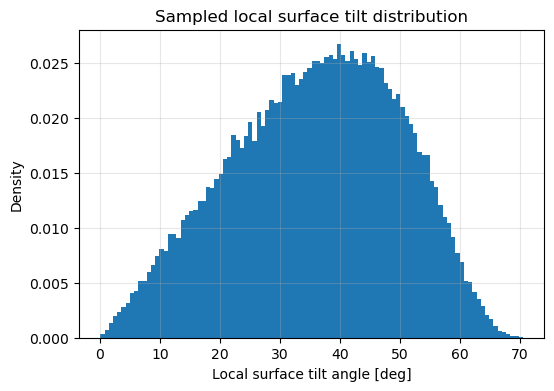

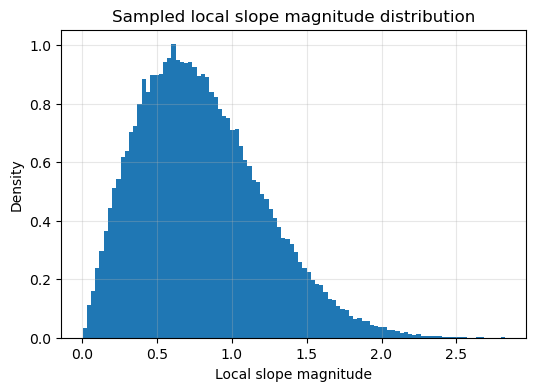

In [21]:
N = 100000
normals = np.array([sim._get_norm_vec(upward=True) for _ in range(N)])

tilt_angle = np.degrees(np.arccos(np.clip(normals[:, 2], -1, 1)))
slope_mag = np.sqrt((normals[:, 0] / normals[:, 2])**2 +
                    (normals[:, 1] / normals[:, 2])**2)

print("mean tilt angle [deg]:", tilt_angle.mean())
print("RMS slope magnitude:", np.sqrt(np.mean(slope_mag**2)))
print("target coarse roughness:", sim.coarse_roughness)

plt.figure(figsize=(6, 4))
plt.hist(tilt_angle, bins=100, density=True)
plt.xlabel("Local surface tilt angle [deg]")
plt.ylabel("Density")
plt.title("Sampled local surface tilt distribution")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(slope_mag, bins=100, density=True)
plt.xlabel("Local slope magnitude")
plt.ylabel("Density")
plt.title("Sampled local slope magnitude distribution")
plt.grid(True, alpha=0.3)
plt.show() 

transmitted
R = 0.0 T = 0.9005560773658785 W = 0.9005560773658785
n_scat = 22 path = 399.988095226846


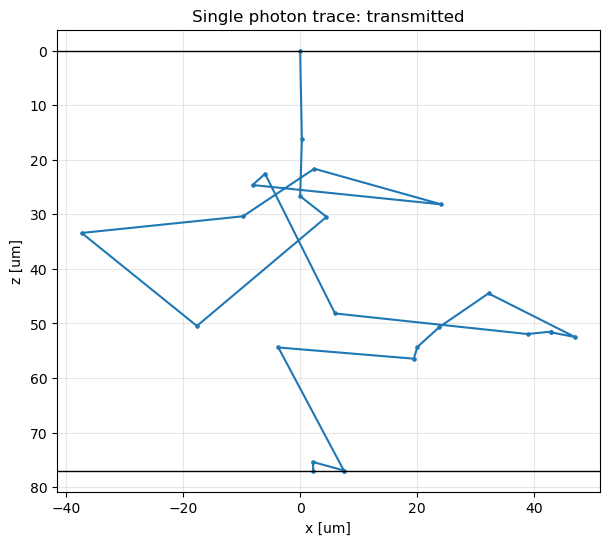

#0 event: start
#1 event: entered
#2 event: bulk_step_move
#3 event: scatter
#4 event: bulk_step_move
#5 event: scatter
#6 event: bulk_step_move
#7 event: scatter
#8 event: bulk_step_move
#9 event: scatter
#10 event: bulk_step_move
#11 event: scatter
#12 event: bulk_step_move
#13 event: scatter
#14 event: bulk_step_move
#15 event: scatter
#16 event: bulk_step_move
#17 event: scatter
#18 event: bulk_step_move
#19 event: scatter
#20 event: bulk_step_move
#21 event: scatter
#22 event: bulk_step_move
#23 event: scatter
#24 event: bulk_step_move
#25 event: scatter
#26 event: bulk_step_move
#27 event: scatter
#28 event: bulk_step_move
#29 event: scatter
#30 event: bulk_step_move
#31 event: scatter
#32 event: bulk_step_move
#33 event: scatter
#34 event: bulk_step_move
#35 event: scatter
#36 event: bulk_step_move
#37 event: scatter
#38 event: bulk_step_move
#39 event: scatter
#40 event: bulk_step_move
#41 event: scatter
#42 event: hit_bottom
#43 event: internal_reflection
#44 event: bulk_step_

In [52]:
n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
n_eff_real = np.real(n_eff_complex)
mu_a = sim._get_mu_a(wvl, n_eff_complex)

phase_norm, csca_sample, diff_sample = sim._get_phase_func_ginoza(
    wavelength=wvl,
    theta_array=theta_array,
    backend="internal",
)
cdf_norm, _ = sim._cdf_phase(phase_norm, theta_array)
l_scat_norm = sim._get_l_scat(csca_sample)

n_p_complex = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_eff_complex=n_eff_complex,
    theta_array=theta_array,
    backend="internal",
)
phase_surf = diff_mie / csca_mie
phase_surf /= 2*np.pi*np.trapezoid(phase_surf*np.sin(theta_array), theta_array)
cdf_surf, _ = sim._cdf_phase(phase_surf, theta_array)
l_scat_surf = sim._get_l_scat(csca_mie)

result = sim._track_single_photon(
    mu_a=mu_a,
    l_scat_norm=l_scat_norm,
    cdf_norm=cdf_norm,
    l_scat_surf=l_scat_surf,
    cdf_surf=cdf_surf,
    theta_array=theta_array,
    n_eff_real=n_eff_real,
    trace=True,
)

print(result["status"])
print("R =", result["R"], "T =", result["T"], "W =", result["W"])
print("n_scat =", result["n_scat"], "path =", result["path"])

trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 6))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.gca().invert_yaxis()  # optional: top surface visually at top
plt.grid(True, alpha=0.3)
plt.show()

for i, e in enumerate(events):
    print(f"#{i} event: {e}")

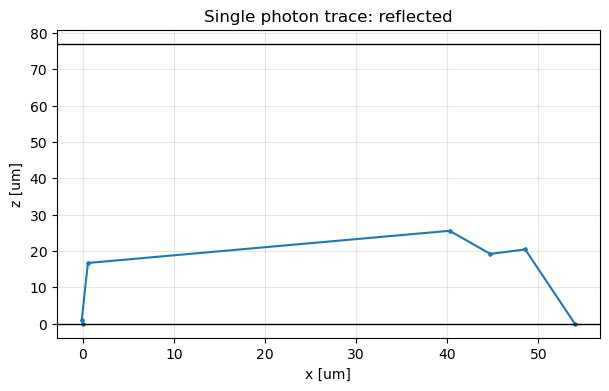

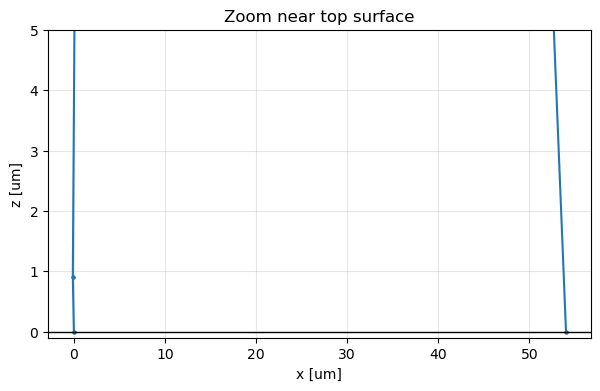

events: ['start', 'entered', 'surface_step_move', 'scatter', 'bulk_step_move', 'scatter', 'bulk_step_move', 'scatter', 'bulk_step_move', 'scatter', 'bulk_step_move', 'scatter', 'hit_top', 'exit_top_reflected']


In [23]:
trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title("Zoom near top surface")
plt.ylim(-0.1, 5.0)
plt.grid(True, alpha=0.3)
plt.show()

print("events:", events[:30])

In [24]:
print("l_scat_norm =", l_scat_norm)
print("l_scat_surf =", l_scat_surf)
print("ratio surf/norm =", l_scat_surf / l_scat_norm)

l_scat_norm = 19.360602010425378
l_scat_surf = 1.1476651746847562
ratio surf/norm = 0.05927838266944161


### 전 파장 시뮬레이션

MC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MC Simulation: 100%|██████████| 1000/1000 [08:29<00:00,  1.96it/s]


mc_77um_test_scale1005.npz is successfully saved!


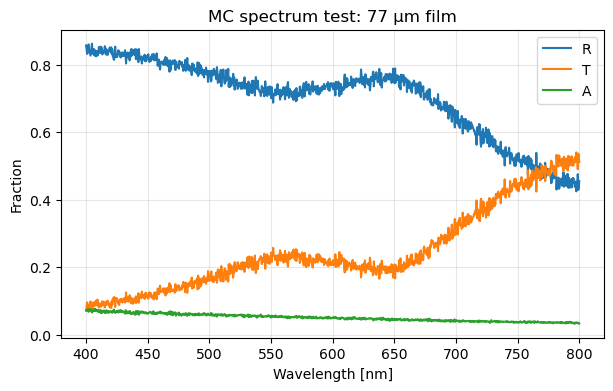

In [47]:
filename = "mc_77um_test_scale1005"

R, T, A, diags = sim.run_simulation(
    wvls=wvl_array,
    theta_array=theta_array,
    N_photons=1000,
    backend="internal",
    use_polydispersity=False,
    return_diagnostics=True,
    save_filename=filename
)

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, R, label="R")
plt.plot(wvl_array * 1000, T, label="T")
plt.plot(wvl_array * 1000, A, label="A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Fraction")
plt.title("MC spectrum test: 77 µm film")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Debugging을 위한 로그 데이터

In [26]:
for d in diags:
    print(
        f"{d['wavelength']*1000:.0f} nm | "
        f"R={R[list(wvl_array).index(d['wavelength'])]:.3f}, "
        f"T={T[list(wvl_array).index(d['wavelength'])]:.3f}, "
        f"A={A[list(wvl_array).index(d['wavelength'])]:.3f} | "
        f"l_norm={d['l_scat_norm']:.3f}, "
        f"l_surf={d['l_scat_surf']:.3f}, "
        f"mu_a={d['mu_a']:.3e}, "
        f"mean_scat={d['mean_scatters']:.1f}, "
        f"status={d['status_count']}"
    )

400 nm | R=0.816, T=0.110, A=0.074 | l_norm=4.519, l_surf=0.469, mu_a=3.344e-04, mean_scat=56.0, status={'reflected': 17224, 'transmitted': 2776, 'absorbed': 0, 'max_events': 0}
400 nm | R=0.827, T=0.102, A=0.071 | l_norm=4.532, l_surf=0.470, mu_a=3.341e-04, mean_scat=53.9, status={'reflected': 17453, 'transmitted': 2547, 'absorbed': 0, 'max_events': 0}
401 nm | R=0.821, T=0.106, A=0.073 | l_norm=4.545, l_surf=0.471, mu_a=3.337e-04, mean_scat=55.0, status={'reflected': 17341, 'transmitted': 2659, 'absorbed': 0, 'max_events': 0}
401 nm | R=0.818, T=0.110, A=0.073 | l_norm=4.558, l_surf=0.473, mu_a=3.334e-04, mean_scat=54.8, status={'reflected': 17251, 'transmitted': 2749, 'absorbed': 0, 'max_events': 0}
402 nm | R=0.827, T=0.101, A=0.071 | l_norm=4.571, l_surf=0.474, mu_a=3.331e-04, mean_scat=53.7, status={'reflected': 17458, 'transmitted': 2542, 'absorbed': 0, 'max_events': 0}
402 nm | R=0.820, T=0.109, A=0.072 | l_norm=4.584, l_surf=0.475, mu_a=3.327e-04, mean_scat=53.9, status={'refl

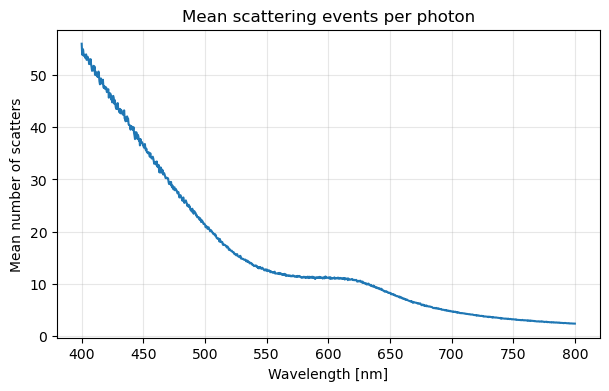

In [27]:
l_norm = np.array([d["l_scat_norm"] for d in diags])
l_surf = np.array([d["l_scat_surf"] for d in diags])
mu_a_arr = np.array([d["mu_a"] for d in diags])
mean_scat = np.array([d["mean_scatters"] for d in diags])

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, mean_scat)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Mean number of scatters")
plt.title("Mean scattering events per photon")
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
for d in diags:
    max_events = d["status_count"].get("max_events", 0)
    if max_events > 0:
        print("max_events warning:", d["wavelength"], max_events)

### Overlay data on the figure from the papaer

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def overlay_figure(filename, img_path, save_path):
    data = np.load(f"{filename}.npz")
    R = data["reflectance"]
    T = data["transmittance"]
    wvls = data["wavelengths"]
    
    # Load Background Image
    img = Image.open(f"{img_path}.png")

    fig, ax = plt.subplots(figsize=(6, 5))

    # Put Reference Image at the background
    ax.imshow(img, extent=[400, 800, 0, 100], aspect="auto")

    # Overlay my graph
    ax.plot(wvl_array*1000, R*100, linewidth=1.0, label="R")
    ax.plot(wvl_array*1000, T*100, linewidth=1.0, label="T")
    ax.set_xlim(400, 800)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("(%)")
    ax.legend()
    plt.savefig(f"{save_path}.png")
    plt.show()
    
    


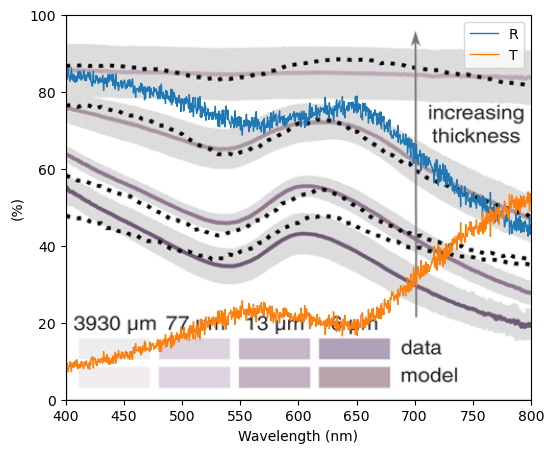

In [48]:
overlay_figure("mc_77um_test_scale1005", "figure3c", "overlayed_data1005")

In [ ]:
R, T, A, diags = sim2.run_simulation(
    wvls=wvl_array,
    theta_array=theta_array,
    N_photons=1000,
    backend="internal",
    use_polydispersity=False,
    return_diagnostics=True,
)

MC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MC Simulation: 100%|██████████| 1000/1000 [06:25<00:00,  2.59it/s]


In [10]:
np.savez(
    "mc_77um_test_v01.npz",
    wavelengths=np.asarray(wvl_array),
    reflectance=R,
    transmittance=T,
    absorbance=A,
)

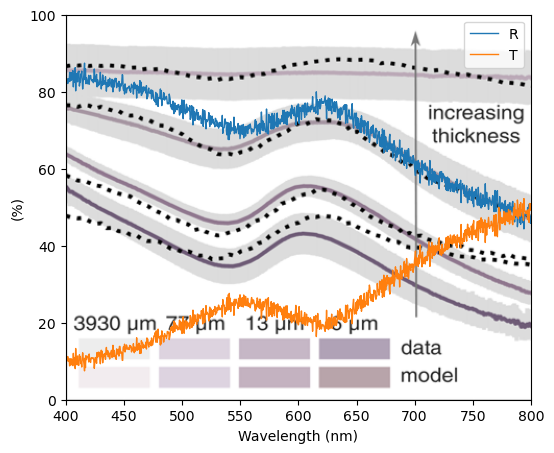

In [13]:
overlay_figure("mc_77um_test_v01", "figure3c", "overlayed_v01")